# Analysis

This notebook shows several different analyses using the Countdown Video Poker Analysis Toolkit. See the [README](../README.md) file for a description of Countdown Video Poker and of CVPAT, and see the [overview](./overview.ipynb) notebook for how to use the toolkit.

# Probabilities

First we'll compute some raw probabilities. The following is the probability of getting a particular kind of hand on the first draw of a deck *without replacement*, by number of decks. The main take-home is that the chance of drawing an *of-a-kind* hand (including pair, flush and full house) increases with the number of decks while the chance of drawing a straight-type hand goes down.

In [121]:
# Compute probabilities of winning hands without replacement
import pandas as pd
import numpy as np

from game import shoe
from game import hand
from stats import hand_stats

# Compute probabilities. HandStats can compute this exactly, so
# no need to sample from multiple trials.
probs = []
for num_decks in range(1, 5):
    cards = shoe.shuffled_cards(num_decks=num_decks,
                                rng=np.random.default_rng())
    hs = hand_stats.HandStats(cards=cards)
    probs.append(hs.prob_winning_hand(held=hand.Hand()) * 100)

freq_names = hand_stats.HandFrequency._fields
probs_no_replacement = pd.DataFrame(probs, columns=freq_names, index=range(1, 5)).T
with pd.option_context('display.precision', 4):
    display(probs_no_replacement)

,1,2,3,4
royal_flush,0.0002,0.0001,0.0001,0.0001
straight_flush,0.0014,0.0013,0.0012,0.0012
five_kind,0.0000,0.0008,0.0014,0.0018
four_kind,0.0240,0.0950,0.1284,0.1470
full_house,0.1441,0.2660,0.3139,0.3391
flush,0.1965,0.2847,0.3175,0.3344
straight,0.3925,0.3549,0.3435,0.3379
three_kind,2.1128,3.3438,3.7623,3.9722
two_pair,4.7539,5.8442,6.2019,6.3794
jack_high_pair,13.0021,13.6877,13.8677,13.9496


The probability of getting a hand *with* replacement depends on which cards you hold. Here's the probability when you try to maximize the payout using the standard 9/6 Jacks-or-better video poker payout table.

In [28]:
# Compute probabilities of winning hands with replacement
import pandas as pd
import numpy as np

from game import payout_table
from stats import hand_stats
from stats import shoe_stats

num_trials = 10

payout = payout_table.PayoutTable(800, 50, 0, 25, 9, 6, 4, 3, 2, 1, 0)

# Compute
points = list(range(-10, -5))
results = []
for num_decks in range(1, 2):
    probs = shoe_stats.probabilities_at_points_trials(
        num_trials=num_trials, points=points, num_decks=num_decks)



  0%|                                                                                                                       | 0/10 [00:02<?, ?it/s]


TypeError: probabilities_at_points() got an unexpected keyword argument 'payout'

In [21]:
import pandas as pd
import numpy as np

from game import payout_table
from stats import hand_stats
from stats import shoe_stats

num_trials = 10

payout = payout_table.PayoutTable(800, 50, 0, 25, 9, 6, 4, 3, 2, 1, 0)
points = list(range(-10, -5))
num_decks = 3

probs = shoe_stats.probabilities_at_points_trials(
    num_trials=num_trials, points=points, num_decks=num_decks)
#probs = np.moveaxis(probs, -1, 0)
#pay = (probs * payout.table[:, np.newaxis, np.newaxis, np.newaxis])
pay = probs * payout.table

pay.shape

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:02<00:00,  3.37it/s]


(10, 5, 32, 12)

In [26]:
amax = pay.argmax(axis=-1)
probs[amax]

(10, 5, 32, 5, 32, 12)

In [2]:
# Compute probabilities of winning hands with replacement
import pandas as pd
import numpy as np

from stats import hand_stats
from stats import shoe_stats

num_trials = 100000

# Compute
points = [0]  # Just top of deck
results = []
for num_decks in range(1, 5):
    results.append(
        shoe_stats.probabilities_at_points_trials(
            num_trials=num_trials, points=points, num_decks=num_decks))

# Display results
freq_names = hand_stats.HandFrequency._fields
means = np.array([r.mean(axis=(0, 1)) for r in results])
probs_df = pd.DataFrame(means, columns=freq_names, index=range(1, 5)).T * 100
with pd.option_context('display.precision', 3):
    display(probs_df)

,1,2,3,4
royal_flush,0.004,0.003,0.003,0.003
straight_flush,0.032,0.027,0.026,0.026
five_kind,0.000,0.020,0.033,0.042
four_kind,0.265,0.932,1.218,1.367
full_house,1.222,2.076,2.367,2.531
flush,2.971,3.936,4.283,4.443
straight,3.500,3.111,2.968,2.909
three_kind,8.811,12.885,14.107,14.734
two_pair,15.210,17.833,18.439,19.027
jack_high_pair,37.701,38.863,38.972,39.043


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [4:02:27<00:00,  6.87it/s]


,royal_flush,straight_flush,five_kind,four_kind,full_house,flush,straight,three_kind,two_pair,jack_high_pair,low_pair,no_hand
106,3.875e-05,2.667e-04,4.084e-04,0.014,0.029,0.045,0.031,0.156,0.216,0.389,0.630,0.823
107,3.857e-05,2.861e-04,3.834e-04,0.014,0.029,0.046,0.031,0.157,0.216,0.391,0.630,0.823
108,3.477e-05,2.905e-04,3.763e-04,0.014,0.029,0.046,0.031,0.158,0.218,0.391,0.631,0.822
109,3.288e-05,2.693e-04,3.857e-04,0.014,0.029,0.046,0.031,0.158,0.219,0.390,0.632,0.822
110,3.848e-05,2.717e-04,4.086e-04,0.014,0.029,0.046,0.031,0.158,0.219,0.390,0.632,0.823
111,3.941e-05,2.811e-04,3.910e-04,0.014,0.030,0.046,0.031,0.159,0.220,0.391,0.633,0.822
112,3.957e-05,2.847e-04,3.968e-04,0.015,0.030,0.046,0.031,0.159,0.220,0.390,0.632,0.823
113,3.462e-05,3.070e-04,3.910e-04,0.014,0.030,0.046,0.032,0.160,0.220,0.391,0.633,0.823
114,3.622e-05,2.987e-04,3.832e-04,0.014,0.030,0.046,0.032,0.160,0.222,0.390,0.634,0.823
115,4.009e-05,2.955e-04,4.093e-04,0.015,0.030,0.046,0.031,0.160,0.223,0.391,0.634,0.823


<AxesSubplot: >

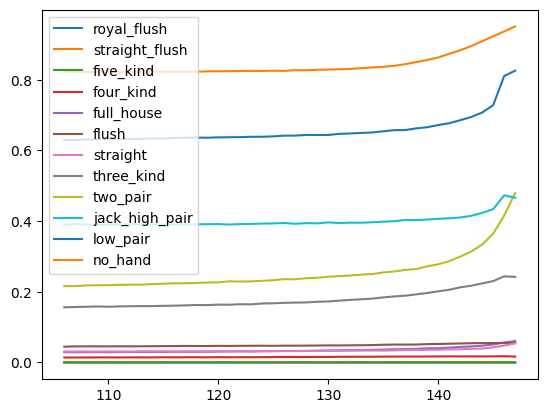

In [22]:
# Compute probabilities of winning hands with replacement
import pandas as pd
import numpy as np

from stats import hand_stats
from stats import shoe_stats

num_trials = 100000
num_decks = 3

shoe_size = num_decks * 52
points = np.arange(-50, -8) + shoe_size
probs = shoe_stats.probabilities_at_points_trials(
    num_trials=num_trials, points=points, num_decks=num_decks)

freq_names = hand_stats.HandFrequency._fields
probs_df = pd.DataFrame(probs.mean(axis=0), columns=freq_names, index=points)
with pd.option_context('display.precision', 3):
    display(probs_df)

probs_df.plot()

<AxesSubplot: >

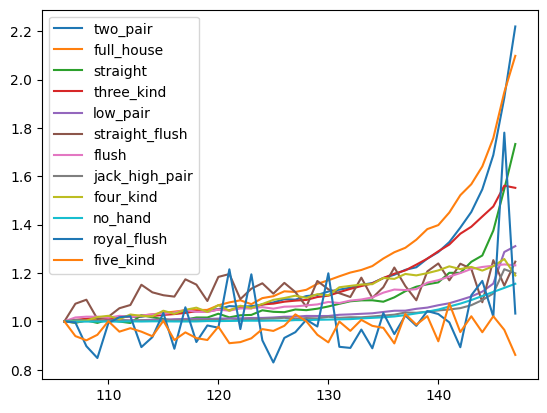

In [108]:
from matplotlib import pyplot as plt
probs_norm = probs_df / probs_df.iloc[0]

indexes_sorted_by_final_value = list(probs_norm.iloc[-1:].T.sort_values(by=147)[::-1].index)

probs_norm[indexes_sorted_by_final_value].plot()
probs_high = probs_norm[indexes_sorted_by_final_value[-3:]]

fig, axes = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
probs_low.plot(ax=axes[0])
probs_high.plot(ax=axes[1])




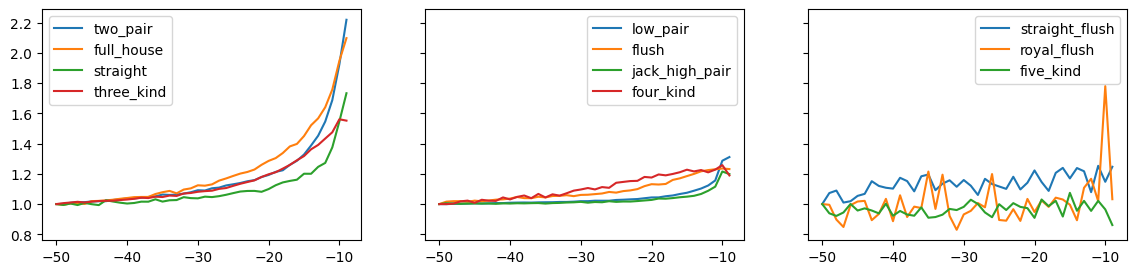

In [132]:
from matplotlib import pyplot as plt
probs_norm = probs_df / probs_df.iloc[0]
probs_norm.set_index(probs_norm.index - 3 * 52, inplace=True)

indexes_high = ['two_pair', 'full_house', 'straight', 'three_kind']
indexes_mid = ['low_pair', 'flush', 'jack_high_pair', 'four_kind']
indexes_low = ['straight_flush', 'royal_flush', 'five_kind']

fig, axes = plt.subplots(ncols=3, figsize=(14, 3), sharey=True)
probs_norm[indexes_high].plot(ax=axes[0])
probs_norm[indexes_mid].plot(ax=axes[1])
probs_norm[indexes_low].plot(ax=axes[2])

#ticks = num_decks * 52 - probs_norm.index
#for ax in axes:
#    ax.set_xticks(ticks)
None



In [106]:
list(probs_norm.iloc[-1:].T.sort_values(by=147)[::-1].index)
indexes_sorted_by_final_value[:-3]

['two_pair',
 'full_house',
 'straight',
 'three_kind',
 'low_pair',
 'straight_flush',
 'flush',
 'jack_high_pair',
 'four_kind']

<AxesSubplot: >

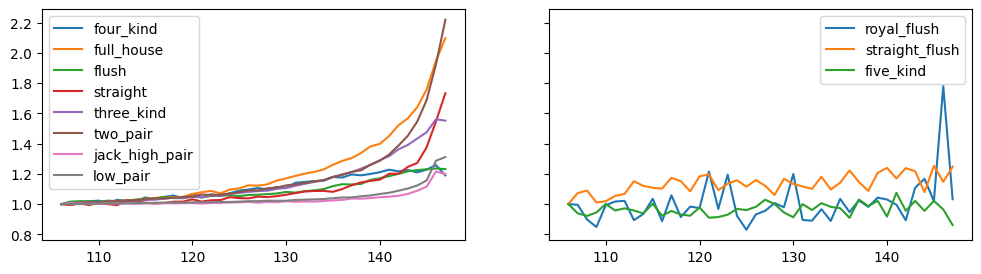

In [63]:
from matplotlib import pyplot as plt

# Split into lower hands (low pair to four-of-a-kind) and high
# hands (five-of-a-kind, straight flush, royal flush) to make
# the plots more readable.
probs_low = probs_df.iloc[:, 3:-1]
probs_high = probs_df.iloc[:, 0:3]

fig, axes = plt.subplots(ncols=2, figsize=(12, 3), sharey=True)
(probs_low / probs_low.iloc[0]).plot(ax=axes[0])

(probs_high / probs_high.iloc[0]).plot(ax=axes[1])

for ax in axes:



In [26]:
#(probs_df[-5:].mean(axis=0) / probs_df[:-10].mean(axis=0)).plot()
np.save('../data/probs_3decks_100k.npy', probs)

,royal_flush,straight_flush,five_kind,four_kind,full_house,flush,straight,three_kind,two_pair,jack_high_pair,low_pair,no_hand
106,0.004,0.038,0.044,1.366,2.810,4.454,3.176,15.513,21.321,38.639,62.541,82.705
107,0.003,0.029,0.038,1.435,2.886,4.548,3.027,15.762,21.750,39.129,62.938,82.376
108,0.005,0.029,0.032,1.345,3.034,4.449,3.108,15.586,22.076,39.116,63.415,82.112
109,0.004,0.028,0.036,1.409,2.949,4.552,3.200,15.623,22.007,39.104,63.087,82.338
110,0.004,0.028,0.036,1.423,2.947,4.629,3.123,15.861,22.141,38.729,63.367,82.137
111,0.003,0.038,0.037,1.459,2.907,4.538,3.046,15.954,21.629,39.373,63.303,82.151
112,0.003,0.026,0.034,1.410,2.891,4.617,3.122,15.883,22.055,38.980,63.192,82.377
113,0.003,0.024,0.035,1.438,3.035,4.532,3.040,15.911,22.288,39.328,62.640,82.454
114,0.003,0.039,0.038,1.494,3.094,4.501,3.161,16.025,22.261,38.869,63.225,82.355
115,0.003,0.027,0.047,1.464,3.156,4.487,3.140,16.336,22.704,39.699,63.684,81.751


<AxesSubplot: >

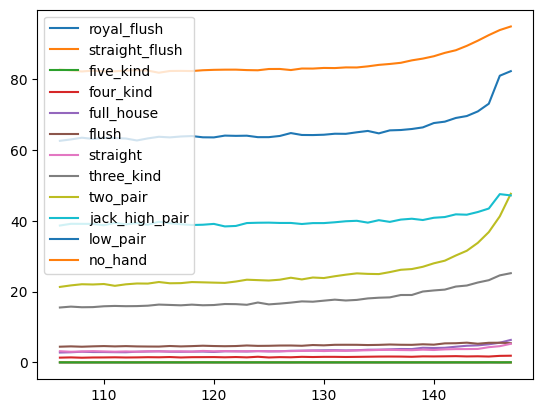

In [3]:
freq_names = hand_stats.HandFrequency._fields
probs_df = pd.DataFrame(probs.mean(axis=0), columns=freq_names, index=points) * 100
with pd.option_context('display.precision', 3):
    display(probs_df)

probs_df.plot()

<AxesSubplot: >

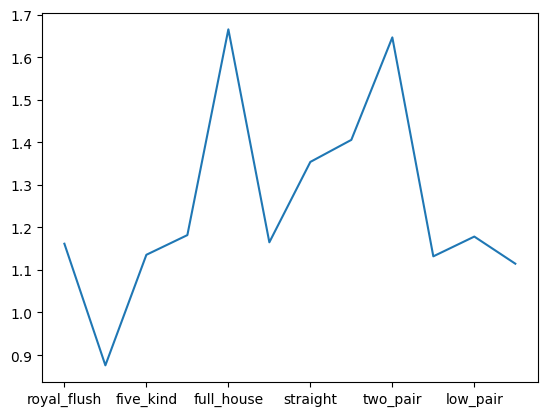

In [26]:
(probs_df[-5:].mean(axis=0) / probs_df[:-10].mean(axis=0)).plot()


## Score distributions

For this set of analyses we use the default list of ten agents to play random games and collect final scores and number of hands played. The following cell will generate data and store it as a CSV. Since running lots of games can take a while we'll then load a cached version of 100,000 games for subsequent analysis.

In [2]:
# Compute game data and optionally write to files
import pandas as pd
from stats import shoe_stats

# Generate a list of games
# scores_load_path = '../data/scores-3deck-100k.csv'
# hands_load_path = '../data/handsplayed-3deck-100k.csv'
scores_load_path = None

if scores_load_path:
    scores_df = pd.read_csv('../data/scores-3deck-100k.csv')
    hands_played_df = pd.read_csv('../data/handsplayed-3deck-100k.csv')
else:
    num_trials = 3000
    num_decks = 3
    hand_limit = 0
    noise_iterations = 2
    allow_short_shoe = True
    scores_save_path = f'../data/scores-{num_decks}deck-{num_trials}.csv'
    hands_save_path = f'../data/handsplayed-{num_decks}deck-{num_trials}.csv'

    # Create a list of games with random shoes.
    games = shoe_stats.generate_games(
        num_games=num_trials, num_decks=num_decks,
        hand_limit=hand_limit, allow_short_shoe=allow_short_shoe)

    # Create agents to play the game. Note that each agent will play in its own copy,
    # so use the returned values rather than relying on fields set in the game objects.
    agents = shoe_stats.default_target_agents(num_decks=num_decks, noise_iterations=noise_iterations)
    game_info_list = shoe_stats.play_games(games, agents)

    scores = [game_info[0] for game_info in game_info_list]
    scores_df = pd.DataFrame(scores, columns=[a.name for a in agents],
                             dtype=int)

    hands_played = [game_info[1] for game_info in game_info_list]
    hands_played_df = pd.DataFrame(hands_played,
                                   columns=[a.name for a in agents], dtype=int)

    if scores_save_path:
        scores_df.to_csv(scores_save_path, index=False, header=True)
        hands_played_df.to_csv(hands_save_path, index=False, header=True)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [1:55:17<00:00,  2.31s/it]


### Mean scores by agent

In [135]:
# Mean scores
from scipy import stats

def conf_int(data: np.ndarray, confidence: float=0.95) -> float:
    """Returns confidence interval of estimated mean.

    Args:
        data: values for which mean is to be estimated.
        confidence: probability that reported mean is within returned interval.

    Returns:
        interval: mean of data = mean ± interval, with given confidence.
    """
    mean = data.mean()
    try:
        interval = stats.norm.interval(
            confidence, loc=mean, scale=stats.sem(data))
    except FloatingPointError:
        return np.nan
    return interval[1] - mean


scores_mean_df = scores_df.mean(axis=0).to_frame(name='mean score')
scores_mean_df['conf (p=.95)'] = conf_int(scores_df)
scores_mean_df['median score'] = scores_df.quantile(.5).astype(int)
scores_mean_df['stddev'] = scores_df.std(ddof=1, axis=0)
scores_mean_df['pct [1k, 10k]'] = ((scores_df >= 1000) & (scores_df < 10000)).mean() * 100
scores_mean_df['pct > 10k'] = (scores_df >= 10000).mean() * 100
scores_mean_df['hands played'] = hands_played_df.mean(axis=0)
scores_mean_df = scores_mean_df.sort_values(by='mean score', ascending=False)

with pd.option_context('display.precision', 2):
    display(scores_mean_df)

,mean score,conf (p=.95),median score,stddev,"pct [1k, 10k]",pct > 10k,hands played
psychic,695.94,3.53,645,568.84,2.45,0.29,21.79
advantage,239.60,1.48,225,239.05,0.30,0.05,22.49
advantage-noise,231.89,1.42,220,229.48,0.25,0.04,22.49
card-counting,230.45,1.45,215,233.48,0.27,0.05,20.25
hands-only,219.60,1.36,205,219.05,0.22,0.04,20.43
risk-averse,219.07,1.22,205,197.43,0.16,0.03,19.70
risk-averse-noise,218.56,1.45,205,234.10,0.22,0.05,20.39
risk-seeking-noise,194.11,1.61,175,260.41,0.34,0.06,19.54
risk-seeking,178.76,1.70,160,274.51,0.37,0.07,19.26
simple,168.32,1.07,155,173.11,0.03,0.03,18.72


In [8]:
# Mean scores
from scipy import stats

def conf_int(data: np.ndarray, confidence: float=0.95) -> float:
    """Returns confidence interval of estimated mean.

    Args:
        data: values for which mean is to be estimated.
        confidence: probability that reported mean is within returned interval.

    Returns:
        interval: mean of data = mean ± interval, with given confidence.
    """
    mean = data.mean()
    try:
        interval = stats.norm.interval(
            confidence, loc=mean, scale=stats.sem(data))
    except FloatingPointError:
        return np.nan
    return interval[1] - mean


scores_mean_df = scores_df.mean(axis=0).to_frame(name='mean score')
scores_mean_df['conf (p=.95)'] = conf_int(scores_df)
scores_mean_df['median score'] = scores_df.quantile(.5).astype(int)
scores_mean_df['stddev'] = scores_df.std(ddof=1, axis=0)
scores_mean_df['pct [1k, 10k]'] = ((scores_df >= 1000) & (scores_df < 10000)).mean() * 100
scores_mean_df['pct > 10k'] = (scores_df >= 10000).mean() * 100
scores_mean_df['hands played'] = hands_played_df.mean(axis=0)
scores_mean_df = scores_mean_df.sort_values(by='mean score', ascending=False)

with pd.option_context('display.precision', 2):
    display(scores_mean_df)

,mean score,conf (p=.95),median score,stddev,"pct [1k, 10k]",pct > 10k,hands played
psychic,688.11,13.99,645,504.83,2.46,0.22,21.82
advantage,238.52,6.09,225,219.83,0.20,0.04,22.52
card-counting,229.64,7.19,215,259.35,0.20,0.06,20.25
advantage-noise-1,229.60,4.74,220,170.99,0.30,0.02,22.59
advantage-noise-2,227.95,4.66,215,168.03,0.24,0.02,22.57
risk-averse,224.50,4.66,210,168.01,0.22,0.02,20.09
card-counting-noise-2,222.18,2.70,210,97.30,0.36,0.00,20.42
hands-only-noise-1,220.32,2.52,210,90.99,0.24,0.00,20.45
card-counting-noise-1,219.75,2.60,210,93.71,0.30,0.00,20.43
hands-only,219.73,7.20,205,259.85,0.16,0.06,20.44


A few things to note from the above stats:

* **Best (non-cheating) score:** *advantage* (240 mean, 225 median)
* **Lowest standard deviation:** *simple* (173), followed by *risk-averse* (197)
* **Most scores above 1000:** *risk-seeking* (0.44%)
* **Games scoring below 100:** about 5%
* **Games *advantage* ranks best:** 23%
* **Games *advantage* ranks worst:** 5%
* **Mean number hands played:** between 19 (simple) to 22.5 (advantage)

In [7]:
scores_df = pd.read_csv('../data/scores-3deck-17agents-5k.csv')
scores_df

,simple,hands-only,card-counting,advantage,risk-averse,risk-seeking,hands-only-noise-1,card-counting-noise-1,risk-averse-noise-1,risk-seeking-noise-1,advantage-noise-1,hands-only-noise-2,card-counting-noise-2,risk-averse-noise-2,risk-seeking-noise-2,advantage-noise-2,psychic
0,230,225,230,335,245,210,220,400,405,195,210,200,275,285,205,355,635
1,180,265,310,305,240,190,170,250,300,220,165,115,305,210,235,345,675
2,135,115,120,350,130,145,150,250,120,155,175,175,155,210,140,115,610
3,285,230,305,235,320,190,225,310,225,190,95,200,290,110,195,235,540
4,245,215,235,235,240,175,305,240,285,175,325,240,255,225,160,230,820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,180,180,190,205,190,100,225,245,100,130,200,120,180,235,205,250,625
4996,195,215,140,325,140,250,380,230,145,205,245,210,135,300,325,125,830
4997,95,215,255,240,215,145,220,160,385,145,255,175,200,365,145,250,1535
4998,110,175,170,195,185,140,225,290,140,125,170,185,245,180,125,125,700


In [9]:
import numpy as np

old_targets = np.sort(scores_df[['simple', 'hands-only', 'card-counting', 'psychic']].values)
for c in (2, 1, 0):
    old_targets[:, c] = np.where(old_targets[:, c] >= old_targets[:, c+1],
                                 old_targets[:, c+1] - 10, old_targets[:, c])


fields = ['simple',
          'hands-only',
          'card-counting',
          'advantage',
          'risk-averse',
          #'risk-seeking', 
          'hands-only-noise-1',
          'card-counting-noise-1',
          'risk-averse-noise-1',
          #'risk-seeking-noise-1',
          'advantage-noise-1',
          'hands-only-noise-2',
          'card-counting-noise-2',
          'risk-averse-noise-2',
          #'risk-seeking-noise-2', 
          'advantage-noise-2',
          'psychic']
target_values = np.array([2, 4, 8, 10]) - 1
target_values = np.array([2, 6, 11, 16]) - 1
target_values = np.array([2, 6, 10, 13]) - 1

new_targets = np.sort(scores_df[fields].values)[:, target_values]

for c in (2, 1, 0):
    new_targets[:, c] = np.where(new_targets[:, c] >= new_targets[:, c+1],
                                 new_targets[:, c+1] - 10, new_targets[:, c])

for c in range(4):
    lt = (new_targets[:, c] < old_targets[:, c]).mean() * 100
    eq = (new_targets[:, c] == old_targets[:, c]).mean() * 100
    gt = (new_targets[:, c] > old_targets[:, c]).mean() * 100
    print(f'{c}: {lt:0.1f}, {eq:0.1f}, {gt:0.1f}')

print()
print((new_targets - old_targets).mean(axis=0))
print(old_targets.mean(axis=0))
print(new_targets.mean(axis=0))


np.sort(scores_df.values)
scores_df.columns

0: 32.7, 26.1, 41.2
1: 37.3, 18.8, 43.9
2: 39.3, 20.8, 39.8
3: 100.0, 0.0, 0.0

[   2.272   -4.559   -6.878 -359.272]
[148.58  206.979 259.892 688.114]
[150.852 202.42  253.014 328.842]


Index(['simple', 'hands-only', 'card-counting', 'advantage', 'risk-averse',
       'risk-seeking', 'hands-only-noise-1', 'card-counting-noise-1',
       'risk-averse-noise-1', 'risk-seeking-noise-1', 'advantage-noise-1',
       'hands-only-noise-2', 'card-counting-noise-2', 'risk-averse-noise-2',
       'risk-seeking-noise-2', 'advantage-noise-2', 'psychic'],
      dtype='object')

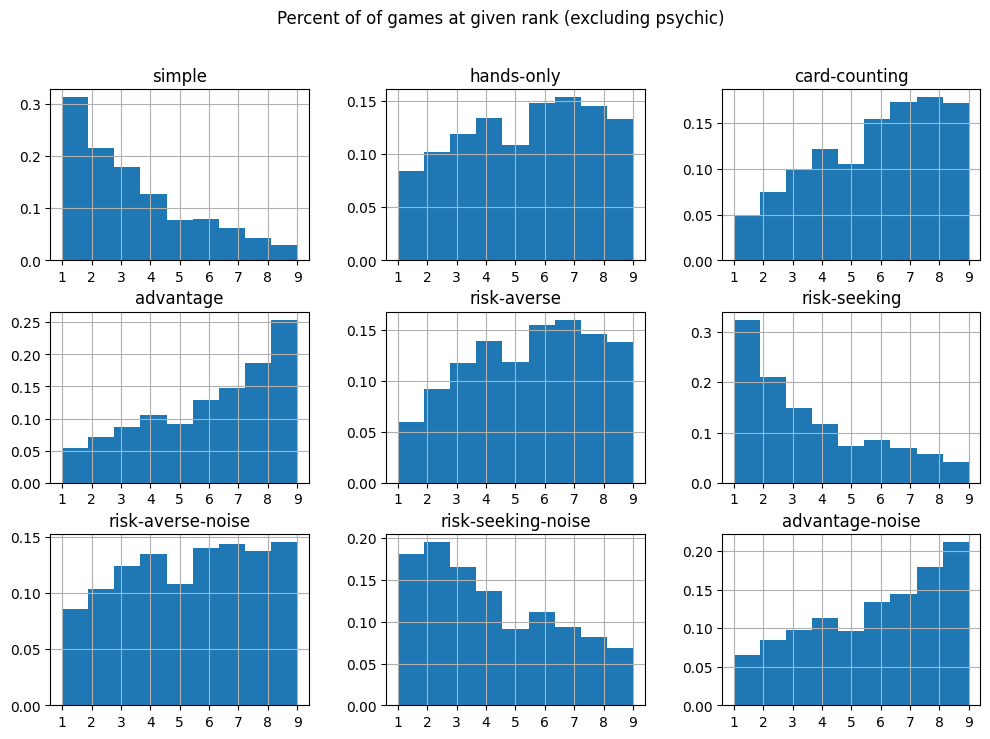

In [136]:
# Show how often each agent is at a particular rank
axes = scores_df.iloc[:, :-1].rank(axis=1).hist(figsize=(12, 8), bins=9, density=True)
for ax in axes.flatten():
    ax.set_xticks(np.arange(1, 10))
_ = plt.gcf().suptitle('Percent of of games at given rank (excluding psychic)')

### How often does *noise* affect the final score?

The default *noise* agents adds Gaussian noise to each evaluated action, with the goal of pushing actions enough to follow a new trajectory without decreasing the mean score more than necessary. Right now the default adds unit Gaussian noise, but is that enough? Too much? That's what this next analysis tries to dial in.

It's ultimately a judement call how you want to trade-off between decrease in mean score and percent of trajectories that differ, but for a default value we'd like to aim for around 95% of scores differing. From the analysis below it looks like we can keep *noise* right at 1.0.

In [22]:
import numpy as np

from agent import player_agent

num_trials = 10000
num_decks = 3
hand_limit = 0
allow_short_shoe = True

# Create a list of games with random shoes.
games = shoe_stats.generate_games(
    num_games=num_trials, num_decks=num_decks,
    hand_limit=hand_limit, allow_short_shoe=allow_short_shoe)

# Create agents to play the game. Note that each agent will play in its own copy,
# so use the returned values rather than relying on fields set in the game objects.
agents = [player_agent.CardCountingAgent(name=f'{noise}', noise=noise)
          for noise in (0.0, 0.5, 0.6, 0.7)] # np.linspace(0, 1, 5)]

game_info_list = shoe_stats.play_games(games, agents)

noise_scores = [game_info[0] for game_info in game_info_list]
noise_scores_df = pd.DataFrame(noise_scores, columns=[a.name for a in agents], dtype=int)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [1:34:16<00:00,  1.77it/s]


,mean delta,conf (p=0.95),pct delta = 0
0.5,-0.94,4.05,8.7
0.6,20.30,27.95,7.3
0.7,17.25,28.29,5.1
0.8,11.37,20.47,5.6


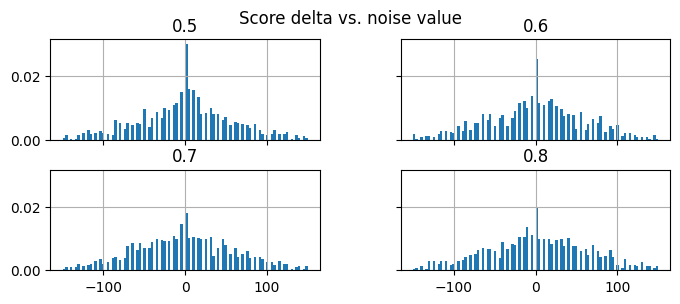

In [21]:
from matplotlib import pyplot as plt

diff = noise_scores_df.iloc[:, 1:] - np.array(noise_scores_df['0.0'])[:, np.newaxis]
diff_mean = diff.mean(axis=0).to_frame(name='mean delta')
diff_mean['conf (p=0.95)'] = conf_int(diff)
diff_mean['pct delta = 0'] = (diff == 0).mean(axis=0) * 100

with pd.option_context('display.precision', 2):
    display(diff_mean)

# Plot histograms
axes = diff[(diff >= -150) & (diff <= 150)].hist(
    bins=100, density=True,
    sharex=True, sharey=True, figsize=(8, 3))
_ = plt.gcf().suptitle('Score delta vs. noise value')


In [17]:
diff

,0.5,0.6,0.7,0.8
0,5,-35,-35,10
1,5,-35,-35,10
2,5,-35,-35,10
3,5,-35,-35,10
4,5,-35,-35,10
...,...,...,...,...
995,5,-35,-35,10
996,5,-35,-35,10
997,5,-35,-35,10
998,5,-35,-35,10


In [139]:
import numpy as np

from agent import player_agent

num_trials = 10000
num_decks = 3
hand_limit = 0
allow_short_shoe = True

# Create a list of games with random shoes.
games = shoe_stats.generate_games(
    num_games=num_trials, num_decks=num_decks,
    hand_limit=hand_limit, allow_short_shoe=allow_short_shoe,
    rng=np.random.default_rng(seed=123456))

# Create agents to play the game. Note that each agent will play in its own copy,
# so use the returned values rather than relying on fields set in the game objects.
agents = [player_agent.CardCountingAgent(name=f'{noise}', noise=noise)
          for noise in np.linspace(0, 1, 5)]

game_info_list = shoe_stats.play_games(games, agents)

noise_scores = [game_info[0] for game_info in game_info_list]
noise_scores_df = pd.DataFrame(noise_scores, columns=[a.name for a in agents], dtype=int)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [2:00:47<00:00,  1.38it/s]


,mean delta,p=0.95,pct delta = 0
0.25,-2.76,4.11,21.07
0.5,-1.75,3.71,7.76
0.75,-4.54,3.77,4.08
1.0,-5.96,3.83,3.40


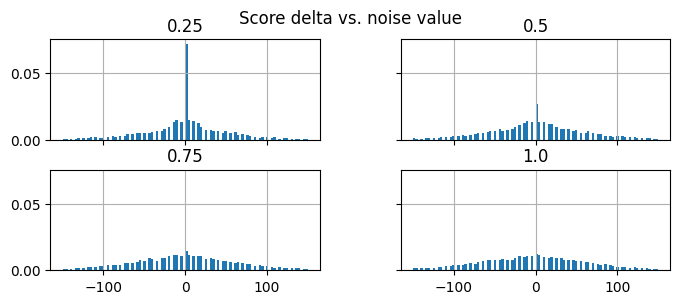

In [153]:
from matplotlib import pyplot as plt

diff = noise_scores_df.iloc[:, 1:] - np.array(noise_scores_df['0.0'])[:, np.newaxis]
diff_mean = diff.mean(axis=0).to_frame(name='mean delta')
diff_mean['conf (p=0.95)'] = conf_int(diff)
diff_mean['pct delta = 0'] = (diff == 0).mean(axis=0) * 100

with pd.option_context('display.precision', 2):
    display(diff_mean)

# Plot histograms
axes = diff[(diff >= -150) & (diff <= 150)].hist(
    bins=100, density=True,
    sharex=True, sharey=True, figsize=(8, 3))
_ = plt.gcf().suptitle('Score delta vs. noise value')


This is a judgement call (and could be dialed in further), but it looks like setting noise to 0.75 is about the point of diminishing returns in terms of shifting the score, though 1.0 isn't too bad. I'll likely change the default to 0.75.

# Hand value vs. depth in shoe

A key feature of Countdown Video Poker is that the expected payout of a hand increases as the game progresses, because fewer cards in the shoe means better information about which cards to hold. This analysis examines the shape of that improvement.

In [46]:
from stats import shoe_stats

probs = shoe_stats.probabilities_along_shoes(
    num_trials=2000, num_decks=3, payout=None, num_processes=None, seed=None)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [17:59<00:00,  1.85it/s]


<AxesSubplot: >

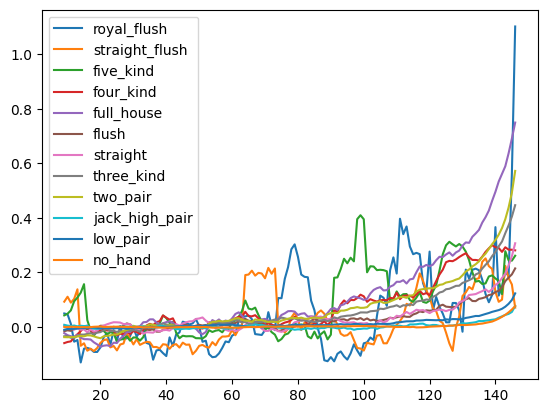

In [94]:
import numpy as np
import pandas as pd

from stats import hand_stats

freq_names = hand_stats.HandFrequency._fields
probs_df = pd.DataFrame(probs.mean(axis=0), columns=freq_names)

mean = probs_df[:78].mean(axis=0)
normalized = probs_df - mean
diff = normalized / mean
diff[:-9].rolling(10).mean().plot()

#_ = probs_df[:-8].plot(figsize=(12, 4), legend=None)


#with pd.option_context('display.precision', 0):
#    display((probs_df[-10:].max(axis=0) - probs_df[:78].mean()) / probs_df[:78].mean() * 100)
#probs_df[:].max(axis=0)

In [29]:
np.save('../data/probs-3deck-2k.npy', probs)

<AxesSubplot: >

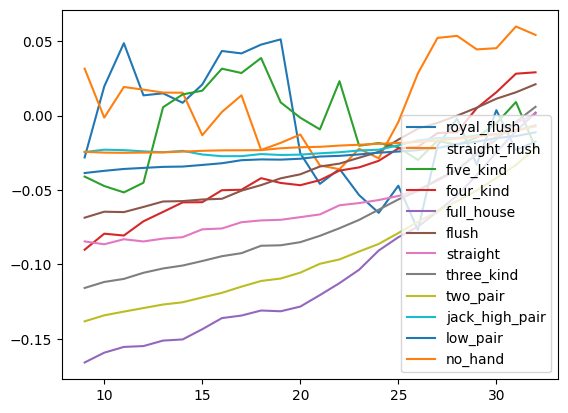

In [27]:
import numpy as np
import pandas as pd

from stats import hand_stats

freq_names = hand_stats.HandFrequency._fields
probs_df = pd.DataFrame(probs.mean(axis=0), columns=freq_names)

mean = probs_df[:78].mean(axis=0)
normalized = probs_df - mean
diff = normalized / mean
diff[:-9].rolling(10).mean().plot()

#_ = probs_df[:-8].plot(figsize=(12, 4), legend=None)


#with pd.option_context('display.precision', 0):
#    display((probs_df[-10:].max(axis=0) - probs_df[:78].mean()) / probs_df[:78].mean() * 100)
#probs_df[:].max(axis=0)

In [53]:
np.where(probs_df == probs_df.max(axis=0))
probs_df.shape

(156, 12)

In [51]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from stats import hand_stats
from game import hand
from game import payout_table
from game import shoe

num_trials = 1000
num_decks = 2
stepsize = 1
payout = payout_table.PayoutTable.default()

shoe_size = 52 * num_decks
results = np.full((num_trials, shoe_size), np.nan)
rng = np.random.default_rng()

def _value_at_point(point):
    cards = shoe.shuffled_cards(num_decks=num_decks, rng=rng)
    delt = hand.Hand(cards[point:point+5])
    hs = hand_stats.HandStats(cards[point+5:], payout=payout)
    return hs.best_expected_payout(delt).value
    
for trial in tqdm(range(num_trials)):    
    for point in np.arange(0, shoe_size, stepsize):
        results[trial, point] = _value_at_point(point)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [1:11:37<00:00,  4.30s/it]


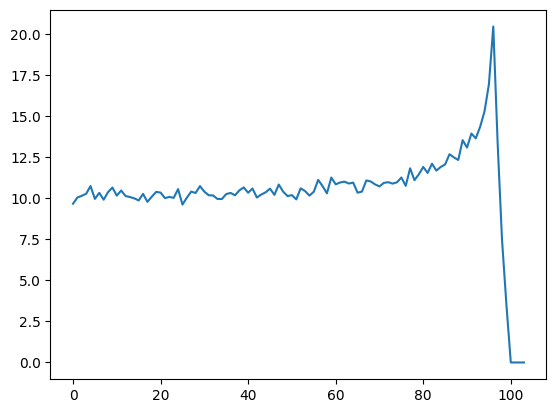

In [52]:
plt.plot(results.mean(axis=0))

In [19]:
results
#mean_df = pd.DataFrame(results.mean(axis=0), index=np.arange(0, shoe_size, stepsize))
#mean_df.plot()

array([[ 4.78082423,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 7.45086038,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 5.07111936,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [13.93939394,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 7.45086038,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 8.19986101,         nan,         nan, ...,         nan,
                nan,         nan]])

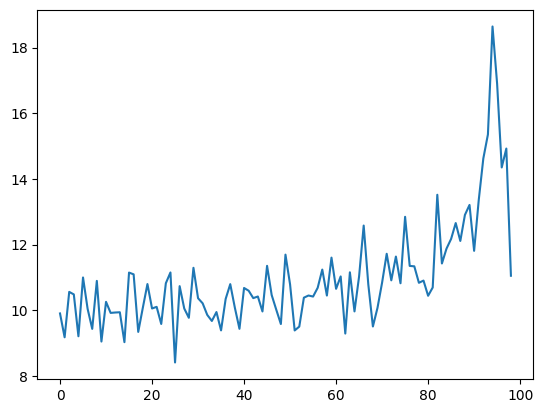

In [10]:
from matplotlib import pyplot as plt

mean = results.mean(axis=0)
plt.plot(mean[:99])


## Payout calibration for straight

**Problem:** People don't go for straights with the current payout table.

**Experiment:** Sweep through different straight values and shoe sizes, keeping the rest of the payout table the same. Track at what level it becomes worthwhile to try for:
* inside straight (2-4-5-6, hoping for 3)
* outside straight (2-3-4-5, hoping for A or 6)
* 2-slot outside straight (3-4-5 hoping for A-2, 2-6 or 6-7)

**Results:**

* Outside straight is already favored most of the time at payout of 4.
* Inside straight reaches 50% favorable at payout of 6.
* Two-slot straight doesn't reach 50% favorable until about 10.

Other insights:
* Straights become less favorable compared to other hands as the shoe gets smaller, since there are usually fewer ways to complete a straight than n-of-a-kind.
* There's not *that* much difference between two and four decks.
* For really small shoes there's no reward that will encourage straights in all cases, because there are some combinations where the card(s) you need are already depleted.
* Straight and flush don't compete much, so these results probably won't change if you also bump the flush payment to keep them in traditional poker-hand order.

In [137]:
#@title Setup
import random

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from tqdm import tqdm

from game import card
from game import hand
from game import shoe
from stats import hand_stats
from game import payout_table

def pct_hands_trying_for_straight(
    init_hand: str, target_held_str: str,
    num_trials: int = 100, num_decks: int = 3,
    min_payout: int = 30, max_payout: int = 100):
  delt = hand.Hand(init_hand)
  target_held = hand.Hand(target_held_str)  
  card_list = shoe.Shoe.shoe_excluding_cards(
    delt.cards, num_decks=num_decks).cards
  shoe_sizes = np.linspace(5, len(card_list), 5).astype(int)
  straight_values = np.arange(min_payout, max_payout+1, 10)
  out = pd.DataFrame(data=0, index=straight_values, columns=shoe_sizes)

  for trial in tqdm(range(num_trials)):
    for shoe_size in shoe_sizes:
      random.shuffle(card_list)
      for straight_value in straight_values:
        payout_t = payout_table.PayoutTable(
            10000, 1000, 200, 80, 70, 60, straight_value, 20, 15, 10, 0)
        ps = hand_stats.HandStats(card_list[:shoe_size], payout=payout_t)
        hv = ps.best_expected_payout(delt)
        if hv.held == target_held:
          out.loc[straight_value, shoe_size] += 1
          break
  return 100 * out.cumsum(axis=0) / num_trials

def plot_pct_hands(data, desc, num_decks, ax=None):
  data.plot(ax=ax, grid=True)
  ax.set_xlabel('Payout for straight')
  ax.set_ylabel('% try straight')
  ax.set_title(f'{desc} ({num_decks} decks)')


# Run trials
num_trials = 100 #@param {type:"integer"}

data = []
for num_decks in range(2, 5):
    inside = pct_hands_trying_for_straight(
        '2C 4D 5H 6S KC', '2C 4D 5H 6S', num_trials, num_decks=num_decks)
    outside = pct_hands_trying_for_straight(
        '2C 3D 4D 5H KC', '2C 3D 4D 5H', num_trials, num_decks=num_decks)
    data.append((inside, outside))


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:55<00:00,  1.79it/s]


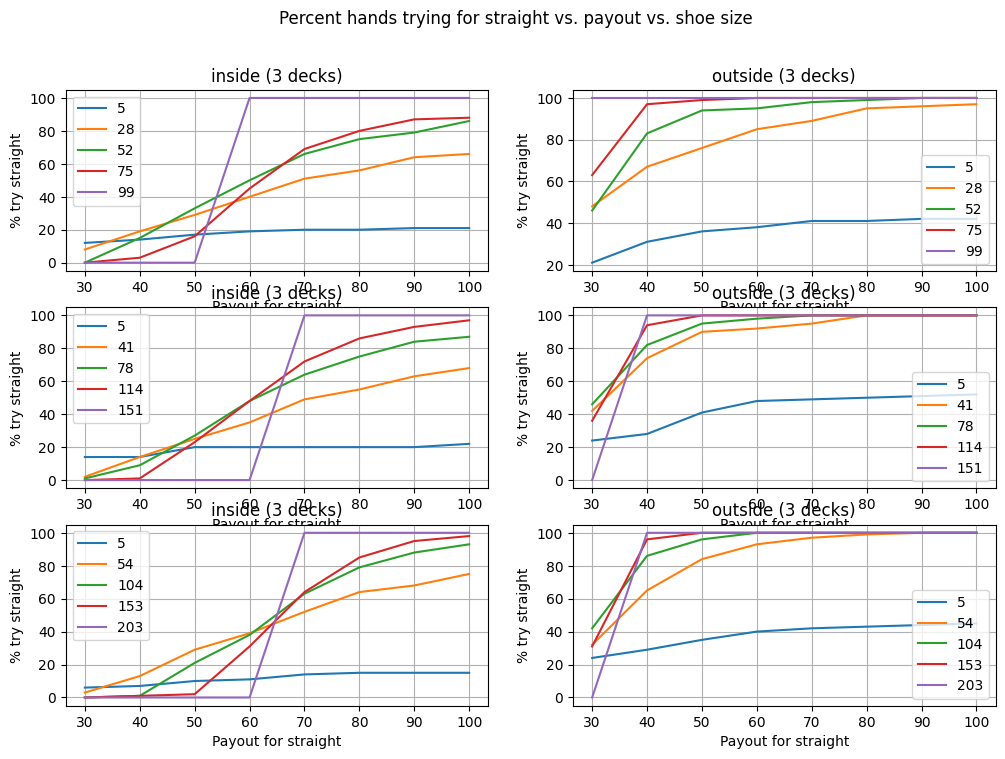

In [141]:

# Plot
fig, axes = plt.subplots(nrows=len(data), ncols=2, figsize=(14, 8))
for row in range(len(data)):
    inside, outside = data[row]
    plot_pct_hands(inside, desc='inside', num_decks=row+2, ax=axes[row][0])
    plot_pct_hands(outside, desc='outside', num_decks=row+2, ax=axes[row][1])

_ = fig.suptitle('Percent hands trying for straight vs. payout vs. shoe size')